In [80]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder,OrdinalEncoder,PolynomialFeatures,LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10,6)


In [ ]:
df = pd.read_csv('spam.csv', encoding='latin-1')
print("Shape of data: " , df.shape)
df.head()

Shape of data:  (5572, 5)


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [64]:
Summary = pd.DataFrame({
    "Dtype" : df.dtypes,
    "missing": df.isnull().sum(),
    "nunique": df.nunique()
})
Summary.sort_values("nunique", ascending=False)


,Dtype,missing,nunique
v2,object,0,5169
Unnamed: 2,object,5522,43
Unnamed: 3,object,5560,10
Unnamed: 4,object,5566,5
v1,object,0,2


In [65]:
df = df.rename(columns={'v1' : 'Label', 'v2': 'Messages'})
print(df.columns.tolist())
print(df.head())

['Label', 'Messages', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4']
  Label  ... Unnamed: 4
0   ham  ...        NaN
1   ham  ...        NaN
2  spam  ...        NaN
3   ham  ...        NaN
4   ham  ...        NaN

[5 rows x 5 columns]


In [66]:
df=df.drop(columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4'])
print(df.columns.tolist())
print(df.shape)
print(df.head())

['Label', 'Messages']
(5572, 2)
  Label                                           Messages
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...


In [67]:
import re
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

ps = PorterStemmer()
stop_words = set(stopwords.words('english'))

In [68]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    words = text.split()
    words = [ps.stem(w) for w in words if w not in stop_words]
    return ' '.join(words)

df['cleaned'] = df['Messages'].apply(clean_text)
print(df[['Messages', 'cleaned']].head())

                                            Messages                                            cleaned
0  Go until jurong point, crazy.. Available only ...  go jurong point crazi avail bugi n great world...
1                      Ok lar... Joking wif u oni...                              ok lar joke wif u oni
2  Free entry in 2 a wkly comp to win FA Cup fina...  free entri wkli comp win fa cup final tkt st m...
3  U dun say so early hor... U c already then say...                u dun say earli hor u c alreadi say
4  Nah I don't think he goes to usf, he lives aro...          nah dont think goe usf live around though


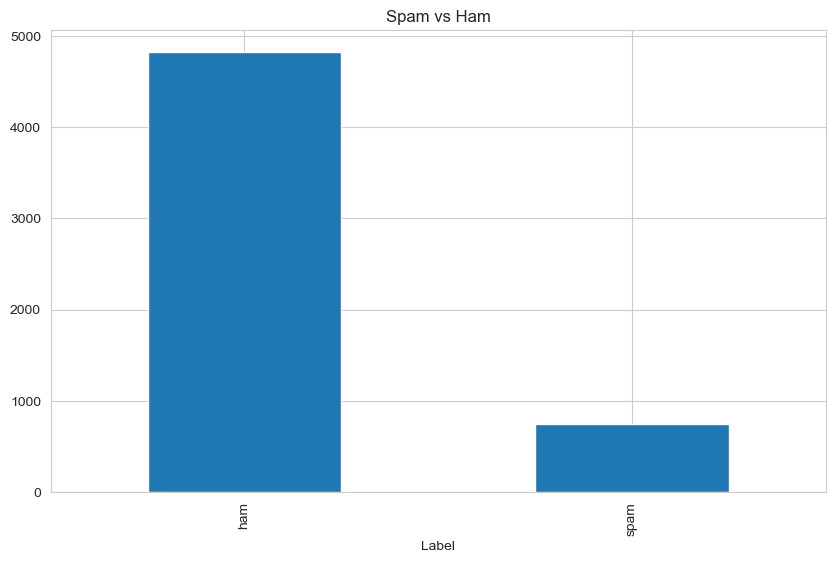

Label
ham      71.023627
spam    138.866131
Name: msg_length, dtype: float64

In [69]:
# 1. Class distribution
df['Label'].value_counts().plot(kind='bar')
plt.title('Spam vs Ham')
plt.show()

# 2. Message length analysis
df['msg_length'] = df['Messages'].apply(len)
df.groupby('Label')['msg_length'].mean()

In [70]:
le = LabelEncoder()
df['Label_enc'] = le.fit_transform(df['Label'])
print(df[['Label', 'Label_enc']].head(10))

  Label  Label_enc
0   ham          0
1   ham          0
2  spam          1
3   ham          0
4   ham          0
5  spam          1
6   ham          0
7   ham          0
8  spam          1
9  spam          1


In [77]:
tfidf = TfidfVectorizer(max_features=3000)
X = tfidf.fit_transform(df['cleaned']).toarray()
y = df['Label_enc']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (5572, 3000)
y shape: (5572,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("Without stratify:")
print("Train spam ratio:", np.sum(y_train==1)/len(y_train))
print("Test spam ratio:", np.sum(y_test==1)/len(y_test))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("\nWith stratify:")
print("Train spam ratio:", np.sum(y_train==1)/len(y_train))
print("Test spam ratio:", np.sum(y_test==1)/len(y_test))

Without stratify:
Train spam ratio: 0.13394660085259144
Test spam ratio: 0.13452914798206278

With stratify:
Train spam ratio: 0.13417096701817366
Test spam ratio: 0.1336322869955157


In [ ]:
nb = MultinomialNB()
nb.fit(X_train, y_train)

lr = LogisticRegression()
lr.fit(X_train, y_train)

rf = RandomForestClassifier()
rf.fit(X_train, y_train)

print("All 3 models trained successfully! ")

All 3 models trained successfully! 


In [81]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

models = {
    'Naive Bayes': nb,
    'Logistic Regression': lr,
    'Random Forest': rf
}

for name, model in models.items():
    y_pred = model.predict(X_test)
    print(f"\n{name}:")
    print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision: {precision_score(y_test, y_pred):.4f}")
    print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
    print(f"F1 Score:  {f1_score(y_test, y_pred):.4f}")


Naive Bayes:
Accuracy:  0.9731
Precision: 0.9917
Recall:    0.8054
F1 Score:  0.8889

Logistic Regression:
Accuracy:  0.9659
Precision: 0.9912
Recall:    0.7517
F1 Score:  0.8550

Random Forest:
Accuracy:  0.9767
Precision: 0.9843
Recall:    0.8389
F1 Score:  0.9058


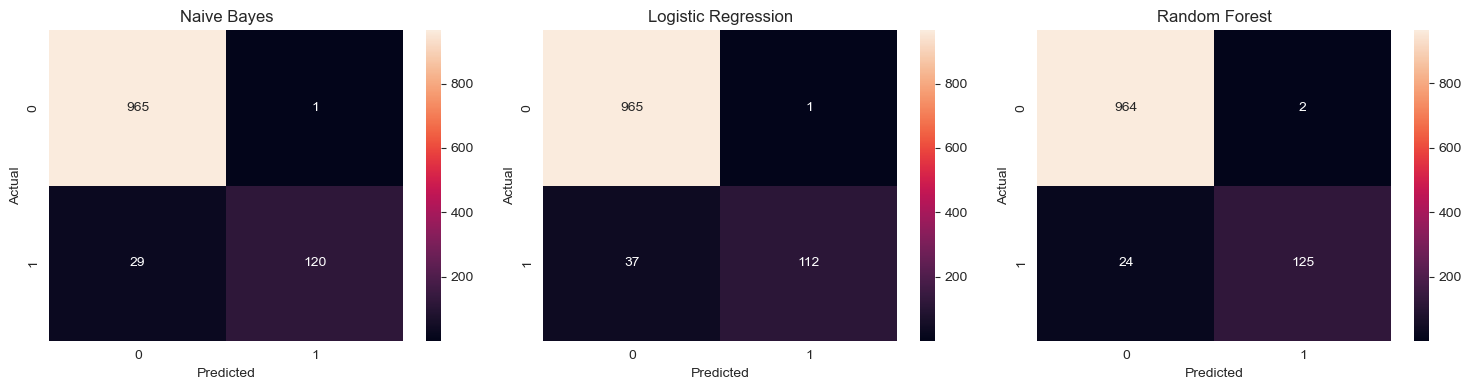

In [82]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(15,4))

for ax, (name, model) in zip(axes, models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', ax=ax)
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

In [ ]:
import pickle

pickle.dump(rf, open('spam_model.pkl', 'wb'))
pickle.dump(tfidf, open('tfidf.pkl', 'wb'))

print("Model saved! ")


Model saved! 
True
True
